# National synthesis

Aggregate per-site `results/{site_id}_summary.csv` files into a comparison table.

In [ ]:
from pathlib import Path
import sys

_REPO_ROOT = Path("..").resolve()
_SRC = _REPO_ROOT / "src"
if _SRC.is_dir() and str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import matplotlib.pyplot as plt
import pandas as pd

from critical_minerals_aster.synthesis import load_site_summaries, write_national_summary

results_dir = _REPO_ROOT / "results"
csv_path = write_national_summary(results_dir)
# Filter to site-level rows only (one row per site) so commodity/earth_mri sub-rows
# do not produce duplicate entries in the national chart.
national = load_site_summaries(results_dir, row_types=["site"])
print(f"Sites in synthesis: {len(national)}")
display(national)

Sites in synthesis: 15


,site_id,site_name,granule_id,n_zones,total_anomaly_km2,median_zone_km2,n_deposits_bbox,n_deposits_in_zones,hit_rate_pct,layout,row_type,commodity_group,earth_mri_category,is_critical_mineral,mineral_system,n_deposits_on_structure,mean_nearest_structure_m
0,bear_lodge,"Bear Lodge, WY",bear_lodge_mosaic,5325,293.87,0.01,125,4,3.2,nested,site,NaN,NaN,False,NaN,4.0,8656.183073
1,climax,"Climax, CO",climax_mosaic,4874,126.72,0.01,874,40,4.6,nested,site,NaN,NaN,False,NaN,38.0,4493.152585
2,darwin,"Darwin, CA",darwin_mosaic,2987,186.29,0.01,262,20,7.6,nested,site,NaN,NaN,False,NaN,10.0,4025.984345
3,goldfield,"Goldfield–Cuprite, NV",AST_L1T_00402072010054840_20250702175723,8625,285.00,0.01,591,29,4.9,nested,site,NaN,NaN,False,NaN,9.0,7877.999323
4,jerome,"Jerome, AZ",jerome_mosaic,2946,101.64,0.01,217,21,9.7,nested,site,NaN,NaN,False,NaN,33.0,2714.226882
5,jerritt_canyon,"Jerritt Canyon, NV",jerritt_canyon_mosaic,3807,334.77,0.02,151,17,11.3,nested,site,NaN,NaN,False,NaN,7.0,4882.756534
6,marysvale,"Marysvale, UT",marysvale_mosaic,9820,351.89,0.01,517,39,7.5,nested,site,NaN,NaN,False,NaN,30.0,4318.008684
7,mcdermitt,"McDermitt Caldera, NV/OR",AST_L1T_00407232010184946_20250705074029,6233,369.97,0.01,126,20,15.9,nested,site,NaN,NaN,False,NaN,10.0,4791.194138
8,mountain_pass,"Mountain Pass, CA",mountain_pass_mosaic,1647,234.67,0.01,380,67,17.6,nested,site,NaN,NaN,False,NaN,0.0,20217.392427
9,oatman,"Oatman, NV/AZ",oatman_mosaic,3502,325.30,0.01,564,20,3.5,nested,site,NaN,NaN,False,NaN,0.0,34582.505945


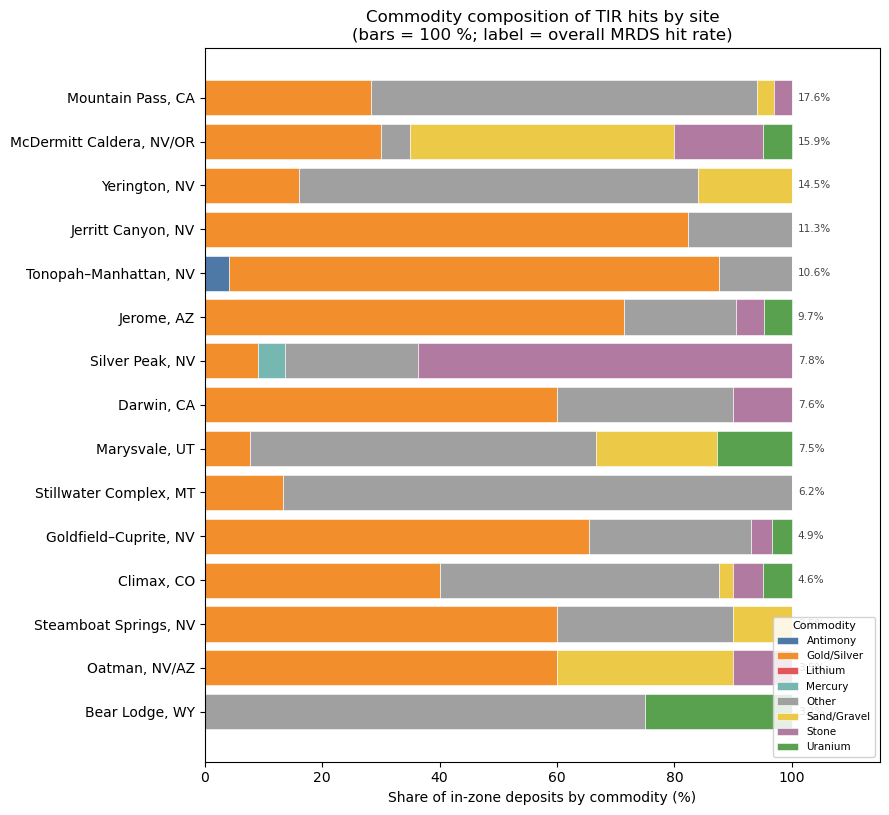

Saved /Users/nicoleaikin/projects/critical-minerals-aster/figures/05_national_hit_rates.png


In [2]:
if len(national) >= 1:
    # Use Earth MRI categories (row_type="earth_mri") instead of the coarse
    # commodity_group so that "Other" is replaced by meaningful sub-groups:
    # Base Metals, REE, Battery Metals, PGM, Specialty/High-Tech, Industrial.
    earth_mri = load_site_summaries(results_dir, row_types=["earth_mri"])

    # Site order: ascending hit rate so the highest appears at the top.
    site_order = national.sort_values("hit_rate_pct", ascending=True)["site_name"].tolist()
    site_hit_rate = national.set_index("site_name")["hit_rate_pct"]

    # Pivot: rows = site_name, cols = earth_mri_category, values = n_deposits_in_zones.
    pivot = earth_mri.pivot_table(
        index="site_name", columns="earth_mri_category",
        values="n_deposits_in_zones", aggfunc="sum", fill_value=0,
    )
    pivot = pivot.reindex(site_order).fillna(0)

    row_totals = pivot.sum(axis=1).replace(0, 1)
    cat_share  = pivot.div(row_totals, axis=0)   # fractions, sum=1 per row

    # Align hit rates to pivot's index order to prevent pandas silently
    # re-sorting indices during the multiply step.
    hr_aligned = site_hit_rate.reindex(pivot.index)
    pivot_abs  = cat_share.mul(hr_aligned, axis=0)   # absolute hit-rate contribution

    # Paul Tol "Muted" palette — validated colorblind-safe for up to 10 categories.
    # https://personal.sron.nl/~pault/#sec:qualitative
    EARTH_MRI_COLORS = {
        "Gold/Silver":                  "#DDCC77",   # sand/gold
        "Base Metals":                  "#88CCEE",   # cyan
        "Non-Critical":                 "#DDDDDD",   # light grey (not the focus)
        "Energy":                       "#CC6677",   # rose (radioactive)
        "Battery Metals \u2013 Co/Ni":     "#44AA99",   # teal
        "Battery Metals \u2013 Li/Brine":  "#117733",   # green (brine/lake)
        "Specialty/High-Tech":          "#332288",   # indigo
        "Industrial":                   "#999933",   # olive
        "REE":                          "#AA4499",   # purple
        "PGM":                          "#882255",   # wine
    }

    # Preferred stacking order: largest / most common first so the dominant
    # segment is flush-left against the axis.
    CAT_ORDER = [
        "Gold/Silver", "Base Metals", "Non-Critical", "Energy",
        "Battery Metals \u2013 Co/Ni", "Battery Metals \u2013 Li/Brine",
        "Specialty/High-Tech", "Industrial", "REE", "PGM",
    ]
    cat_cols  = [c for c in CAT_ORDER if c in pivot_abs.columns]
    cat_cols += [c for c in pivot_abs.columns if c not in cat_cols]

    fig, ax = plt.subplots(figsize=(10, max(3, len(site_order) * 0.6)))
    left = pd.Series(0.0, index=pivot_abs.index)
    for cat in cat_cols:
        vals = pivot_abs[cat]
        ax.barh(pivot_abs.index, vals, left=left,
                color=EARTH_MRI_COLORS.get(cat, "#AAAAAA"),
                label=cat, edgecolor="white", linewidth=0.4)
        left = left + vals

    ax.set_xlim(0, 20)
    ax.set_xlabel("MRDS hit rate (% of deposits in strong TIR zones)")
    ax.set_title("Alteration\u2013deposit correlation by site\n"
                 "(colour = Earth MRI commodity category of in-zone deposits)")
    ax.legend(
        loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0,
        fontsize=7.5, title="Earth MRI category", title_fontsize=8,
        framealpha=0.9,
    )
    plt.tight_layout()
    out = _REPO_ROOT / "figures" / "05_national_hit_rates.png"
    out.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")